Downloading the dataset

In [ ]:
!kaggle datasets download -d subirbiswas19/skin-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/subirbiswas19/skin-disease-dataset
License(s): CC0-1.0
skin-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile

with ZipFile("skin-disease-dataset.zip", "r") as zip_ref:
  zip_ref.extractall()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import from tensorflow.keras

Checking no of images

In [ ]:
import os
train_dir  ="/content/skin-disease-datasaet/train_set"
total_train_images  =0

for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    num_images = len(os.listdir(category_dir))
    total_train_images += num_images

print("Total no of training images: ", total_train_images)

Total no of training images:  925


In [ ]:
test_dir = "/content/skin-disease-datasaet/test_set"
total_test_images  =0

for category in os.listdir(test_dir):
  category_dir = os.path.join(test_dir , category)
  num_images = len(os.listdir(category_dir))
  total_test_images += num_images

print("Total no of test images: ", total_test_images)

Total no of test images:  234


Seeing some sample images

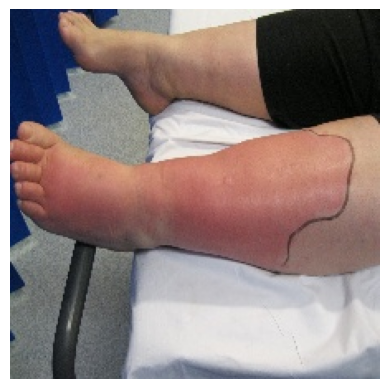

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_dir = "/content/skin-disease-datasaet/train_set/BA- cellulitis/BA- cellulitis (1).jpeg"
img = mpimg.imread(img_dir)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
print(img.shape)

(224, 224, 3)


Data Augmantation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

#train&test generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)


Found 924 images belonging to 8 classes.
Found 233 images belonging to 8 classes.


In [ ]:
train_dir  ="/content/skin-disease-datasaet/train_set"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size =(224, 224), # Change target size to match model input
    class_mode="categorical",
    batch_size = 32
)

Found 924 images belonging to 8 classes.


In [ ]:
test_dir = "/content/skin-disease-datasaet/test_set"

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224,224), # Change target size to match model input
    class_mode="categorical",
    batch_size = 32
)

Found 233 images belonging to 8 classes.


In [ ]:
from keras.applications import MobileNet
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.models import Model

#download mobilenet
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

# add specific layers for the main layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)


In [ ]:
# train the model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 741ms/step - accuracy: 0.2342 - loss: 2.4766 - val_accuracy: 0.7725 - val_loss: 0.9656 - learning_rate: 0.0010
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.5752 - loss: 1.2106 - val_accuracy: 0.8670 - val_loss: 0.5511 - learning_rate: 0.0010
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 302ms/step - accuracy: 0.6689 - loss: 0.8904 - val_accuracy: 0.8627 - val_loss: 0.4986 - learning_rate: 0.0010
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 317ms/step - accuracy: 0.7765 - loss: 0.7167 - val_accuracy: 0.9227 - val_loss: 0.3274 - learning_rate: 0.0010
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.8322 - loss: 0.5366 - val_accuracy: 0.8798 - val_loss: 0.3403 - learning_rate: 0.0010
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 332ms/step - accuracy: 0.8296 - loss: 0.5195 - val_accuracy: 0.9270 - val_loss: 0.2663 - learning_rate: 0.0010
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 328ms/step - accuracy: 0.8579 - loss: 0.4696 - val_

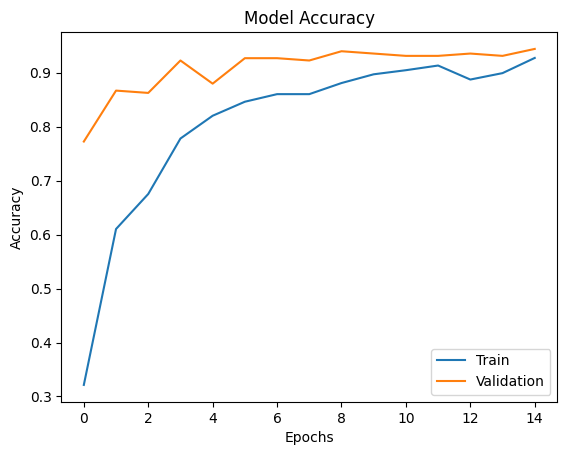

In [ ]:
h = history

plt.plot(h.history["accuracy"])
plt.plot(h.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
# evaluate the model
train_loss, train_acc = model.evaluate(train_generator)
test_loss, test_acc = model.evaluate(test_generator)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - accuracy: 0.9717 - loss: 0.1112
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9483 - loss: 0.1614
Training Accuracy: 97.73%
Test Accuracy: 94.42%


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step
Confusion Matrix:
 [[7 4 5 3 3 4 0 7]
 [1 0 6 3 1 3 6 0]
 [5 3 4 7 1 5 4 3]
 [4 3 5 4 4 3 5 5]
 [2 3 3 5 2 2 3 3]
 [3 1 3 3 3 3 6 3]
 [7 4 4 0 3 1 7 8]
 [3 2 6 8 3 3 3 5]]


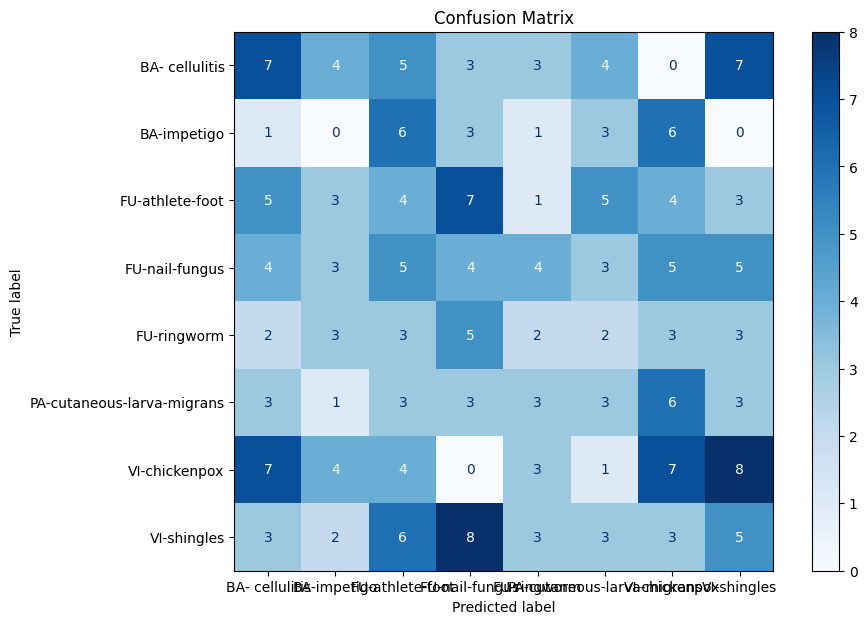

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

# Predict the classes for test data
test_predictions = model.predict(test_generator, verbose=1)

# Get the predicted class labels
test_pred_classes = np.argmax(test_predictions, axis=1)

# Get true class labels for the test set
true_labels = test_generator.classes

# Class names (same order as used in train_generator)
class_names = list(test_generator.class_indices.keys())

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, test_pred_classes, labels=range(len(class_names)))
print("Confusion Matrix:\n", cm)

# Display the confusion matrix
plt.figure(figsize=(10, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title("Confusion Matrix")
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
#test acc
print(f"Test Accuracy: {test_acc * 100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9476 - loss: 0.1763
Test Accuracy: 94.42%


In [ ]:
model.save("model.h5")

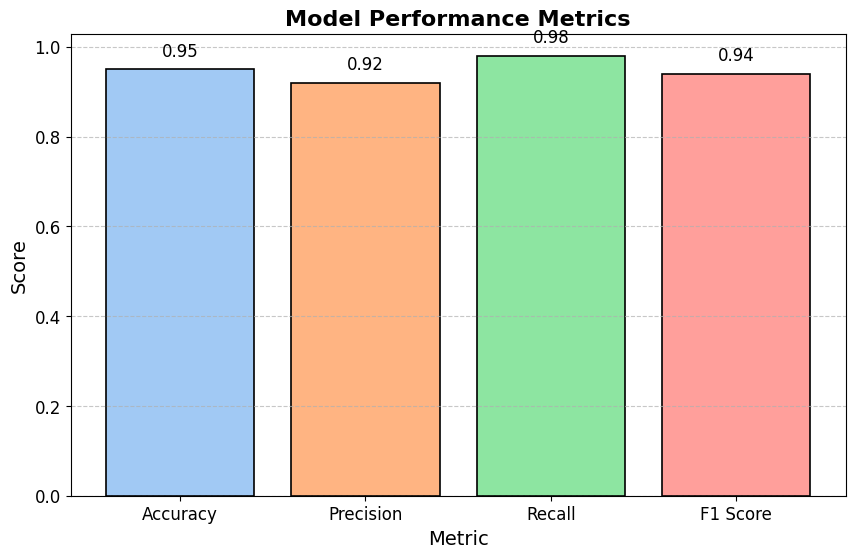

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


colors = sns.color_palette("pastel")[0:4]


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

values = [0.95, 0.92, 0.98, 0.94]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)


plt.title('Model Performance Metrics', fontsize=16, weight='bold')
plt.xlabel('Metric', fontsize=14)
plt.ylabel('Score', fontsize=14)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=12)


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.savefig('performance_metrics_improved.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files
files.download('model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save('Skin_Disease_model.keras')


In [ ]:
from google.colab import files
files.download('Skin_Disease_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>